### Summary  
This notebook loads the watershed boundary shapefile (186 polygons), inspects attributes, and visualizes the polygons with their watershed IDs.  
It also calculates the total number of watersheds, basic geometric attributes (area, perimeter), and provides tools to summarize or plot them.  
These watershed units can later be reprojected and enriched with morphometric and rainfall data for flash flood modeling.  

Shape file downloaded from https://nsdi.systems.gov.bt/data/Boundaries


In [1]:
import geopandas as gpd

# Load shapefile
watershed = gpd.read_file("../../186 Watershed boundary/186 Watershed boundary.shp")

# Inspect
print(watershed.head())

         f_area  ws_id           area_ha     area_ha_1     SHAPE__Len  \
0  1.403314e+08      1  14033.1356069597  14033.135607   88962.631299   
1  1.069433e+08      2   10694.331035308  10694.331035   72762.793824   
2  1.634449e+08      3  16436.0007344264  16436.000734   87853.120695   
3  2.076810e+08      4  20768.1036079112  20768.103608  100646.751220   
4  9.158350e+07      5  9158.35047410094   9158.350474   62076.446669   

     SHAPE__Are                                           geometry  
0  1.783218e+08  POLYGON ((10245897.804 3155396.599, 10245640.9...  
1  1.380322e+08  POLYGON ((9990796.024 3272558.723, 9990916.261...  
2  2.119142e+08  POLYGON ((9977078.645 3269692.821, 9977264.969...  
3  2.681361e+08  POLYGON ((9997299.005 3278803.177, 9997517.596...  
4  1.181974e+08  POLYGON ((10034395.122 3273465.314, 10034625.4...  


In [2]:
print(watershed.crs)

EPSG:3857


### Watershed Shapefile CRS Info

- **File:** `186 Watershed boundary.shp`
- **Current CRS:** `EPSG:3857` (*WGS 84 / Pseudo-Mercator*)  
  - Common for web maps (Google Maps, OpenStreetMap).  
  - Units: **meters** (not degrees).  

⚠️ Note: For overlay with climate/weather data (ERA5, ECMWF, GraphCast) or geospatial data in Bhutan, it may be preferable to convert to:  
- `EPSG:4326` (*WGS 84, lat/lon, degrees*), or  
- `EPSG:32646` (*UTM Zone 46N, meters*).  

Conversion example in Python:
```python
watershed = watershed.to_crs(epsg=4326)  # convert to lat/lon


Total number of watershed polygons: 186


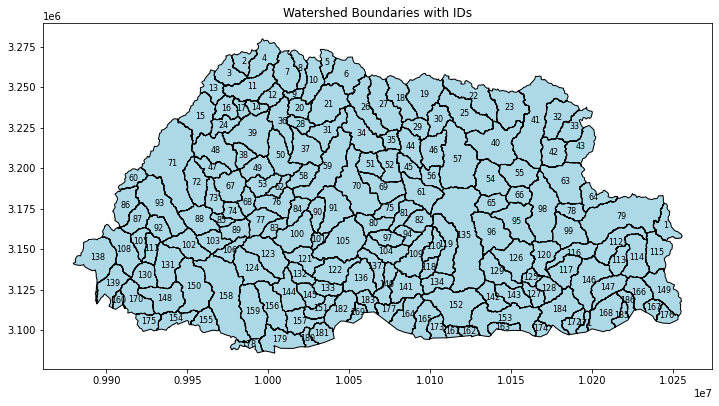

In [3]:
import matplotlib.pyplot as plt

# Number of watersheds
n_watersheds = len(watershed)
print(f"Total number of watershed polygons: {n_watersheds}")

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
watershed.plot(ax=ax, edgecolor="black", facecolor="lightblue")

# Add labels (using ws_id)
for idx, row in watershed.iterrows():
    # Use centroid for label placement
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, str(row["ws_id"]),
            fontsize=8, ha="center", va="center")

plt.title("Watershed Boundaries with IDs")
plt.show()


In [4]:
# Compute area (m²) and perimeter (m)
watershed["area_m2"] = watershed.geometry.area
watershed["area_km2"] = watershed["area_m2"] / 1e6  # convert to km²
watershed["perimeter_m"] = watershed.geometry.length

# Summary statistics
summary = {
    "Total watersheds": len(watershed),
    "Total area (km²)": watershed["area_km2"].sum(),
    "Average area (km²)": watershed["area_km2"].mean(),
    "Min area (km²)": watershed["area_km2"].min(),
    "Max area (km²)": watershed["area_km2"].max(),
    "Average perimeter (km)": (watershed["perimeter_m"].mean() / 1000),
    "Min perimeter (km)": (watershed["perimeter_m"].min() / 1000),
    "Max perimeter (km)": (watershed["perimeter_m"].max() / 1000),
}
for k, v in summary.items():
    print(f"{k}: {v:.2f}")


Total watersheds: 186.00
Total area (km²): 49285.00
Average area (km²): 264.97
Min area (km²): 55.22
Max area (km²): 1156.66
Average perimeter (km): 101.66
Min perimeter (km): 41.02
Max perimeter (km): 282.94


### Use of Watershed Boundaries for Flash Flood Modeling

- **Current layer:** 186 watershed polygons (EPSG:3857, pseudo-Mercator).
- **Recommended CRS for hydrology in Bhutan:**
  - EPSG:32646 (UTM Zone 46N, meters) – most of Bhutan
  - EPSG:32645 (UTM Zone 45N) – far west
- **Why reproject?**
  - Hydrologic and morphometric calculations (area, slope, length) require a metric CRS.

#### Key Prep Steps
1. **Reproject** to EPSG:32646.
2. **QA/QC geometries** – fix invalid polygons, check overlaps, remove slivers.
3. **Derive morphometrics** (using DEM):
   - Area (km²), perimeter
   - Mean slope, elevation range
   - Longest flow path, stream order
4. **Sub-basin size**: For flash flood modeling, target 5–200 km².
   - Split large polygons if needed.
5. **Rainfall data**:
   - Preferred: gauges, radar, IMERG/GPM (30–60 min).
   - ERA5 hourly can be used for broad screening but may smooth flash events.
6. **Hydrologic parameters**:
   - Land cover + soils → Curve Number (CN) or Green-Ampt
   - Time of Concentration (Tc)
7. **Model choices**:
   - HEC-HMS (fast, rainfall–runoff)
   - GSSHA (gridded, flash flood friendly)
   - LISFLOOD-FP / HEC-RAS 2D (for inundation routing)
   - SWMM (urban)

#### Workflow Outline
- Reproject → Clean polygons → Extract attributes (DEM, land cover, soils)  
- Build **per-basin hyetographs** from rainfall inputs  
- Calibrate parameters (CN, Tc)  
- Run rainfall–runoff + routing model  

#### Example Code Stub
```python
# Reproject and basic attributes
ws = watershed.to_crs(32646)
ws["area_km2"] = ws.area / 1e6
ws["perimeter_km"] = ws.length / 1000
